# Análise exploratória
Este notebook tem como objetivo:
- Analisar os dados brutos disponíveis
- Verificar inconsistências nos dados
- Entender sobre as dinâmicas das filiais e regras de negócio
- Achar e entender padrões de sazonalidade
- Garantir que os dados estejam limpos, entendíveis e estatisticamente otimizados para a modelagem

# Setup

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PATH_VENDAS = 'Data/raw/fato_vendas_varejo.parquet'
PATH_METAS = 'Data/raw/metas_vendas_varejo.parquet'
PATH_FILIAIS = 'Data/raw/filiais.parquet'
PATH_CALENDARIO = 'Data/CSVs/calendario_varejo.csv'

os.getcwd()
pd.set_option('display.float_format', '{:.2f}'.format)

### Leitura de dados

In [9]:
df_vendas = pd.read_parquet(PATH_VENDAS)
df_metas = pd.read_parquet(PATH_METAS)
df_filiais = pd.read_parquet(PATH_FILIAIS)
df_calendario = pd.read_csv(PATH_CALENDARIO)

# Análise

## Natureza dos dados
Vamos fazer investigação inicial dos dados disponíveis, analisando coisas como:
- Número de linhas
- Valores nulos e inconsistentes
- Distribuição dos dados
- Janela temporal

### Vendas

Observações:
- Sem valores nulos
- 1 ano de dados
- 125 filiais unicas
- Tabela grande
- Faturamento máximo absurdamente grande, investigar possível B2B ou erro de lançamento

In [10]:
# Estrutura, tipos de dados e consumo de memoria
df_vendas.info()
display(df_vendas.head())
print(df_vendas.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5534166 entries, 0 to 5534165
Data columns (total 5 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   codigo_documento_saida  int64  
 1   codigo_filial           int64  
 2   data_emissao            str    
 3   quantidade              float64
 4   faturamento             float64
dtypes: float64(2), int64(2), str(1)
memory usage: 332.5 MB


,codigo_documento_saida,codigo_filial,data_emissao,quantidade,faturamento
0,122854,1803,2025-07-07 00:00:00.000,6.00,135.00
1,214007,1743,2025-07-18 00:00:00.000,9.00,222.63
2,176406,1794,2025-07-17 00:00:00.000,3.00,389.45
3,999220,1614,2025-07-01 00:00:00.000,39.00,707.20
4,181499,1761,2025-06-02 00:00:00.000,15.00,194.43


codigo_documento_saida    0
codigo_filial             0
data_emissao              0
quantidade                0
faturamento               0
dtype: int64


In [11]:
# Numero de valores unicos
colunas_analise = ['codigo_filial','codigo_documento_saida']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {len(df_vendas[coluna].unique())}")

# Distribuição dos valores numéricos e ts
df_vendas['data_emissao'] = pd.to_datetime(df_vendas['data_emissao'])
display(df_vendas[['quantidade','faturamento','data_emissao']].describe())

# Normalização preventiva das colunas de data (zerar horas/minutos/segundos)
df_vendas['data_emissao'] = df_vendas['data_emissao'].dt.normalize()

# Filial para string
df_vendas['codigo_filial'] = df_vendas['codigo_filial'].astype(str)

Valores únicos em 'codigo_filial': 125
Valores únicos em 'codigo_documento_saida': 1755854


,quantidade,faturamento,data_emissao
count,5534166.00,5534166.00,5534166
mean,7.78,208.95,2025-07-10 11:48:00.156902
min,3.00,0.03,2025-01-01 00:00:00
25%,3.00,45.48,2025-04-09 00:00:00
50%,6.00,106.73,2025-07-14 00:00:00
75%,9.00,252.76,2025-10-13 00:00:00
max,21600.00,627414.75,2025-12-31 00:00:00
std,40.51,1005.36,NaN


### Metas

Observações:
- Sem valores nulos
- Investigar extremos de meta (0 e 413956.34)
- 125 filiais unicas
- "meta_n_med" se refere a **meta** para **NÃO MEDICAMENTOS**, mas o valor de **faturamento** da tabela de **VENDAS** é **geral**.
    - Será considerada uma **mesma escala**, ou seja, o **faturamento das vendas** será considerado **NÃO MEDICAMENTOS**.
    - Do contrário, seria impossível estimar a eficácia das metas atuais, já que não está especificado um valor para não medicamentos em VENDAS.

In [12]:
# Estrutura, tipos de dados e consumo de memoria
df_metas.info()
display(df_metas.head())

<class 'pandas.DataFrame'>
RangeIndex: 42896 entries, 0 to 42895
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   codigo_filial    42896 non-null  int64  
 1   data_meta_venda  42896 non-null  str    
 2   meta_n_med       42896 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.9 MB


,codigo_filial,data_meta_venda,meta_n_med
0,1740,2025-01-01 03:00:00.000,4652.32
1,1830,2025-01-01 03:00:00.000,7870.85
2,1524,2025-01-01 03:00:00.000,6144.89
3,1677,2025-01-01 03:00:00.000,11840.37
4,1758,2025-01-01 03:00:00.000,9554.39


In [13]:
# Numero de valores unicos
colunas_analise = ['codigo_filial']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {len(df_metas[coluna].unique())}")
    
# Distribuição dos valores numéricos e ts
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda'])
display(df_metas[['meta_n_med','data_meta_venda']].describe())

# Normalização preventiva das colunas de data (zerar horas/minutos/segundos)
df_metas['data_meta_venda'] = df_metas['data_meta_venda'].dt.normalize()

# Filial para string
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)

Valores únicos em 'codigo_filial': 125


,meta_n_med,data_meta_venda
count,42896.00,42896
mean,27969.85,2025-07-05 01:32:31.063036
min,0.00,2025-01-01 03:00:00
25%,18272.51,2025-04-05 03:00:00
50%,24647.02,2025-07-06 03:00:00
75%,33038.51,2025-10-05 03:00:00
max,413956.34,2025-12-31 03:00:00
std,17684.89,NaN


### Filiais

Observações:
- Sem valores nulos
- Colunas de valores binários serão transformadas em numéricas para modelagem
- UF constante -> deletar
- codigo_filial unicos -> 124 (investigar divergência com vendas e metas)
- codigo_filial estava como object, o padrão é int64

In [14]:
# Estrutura, tipos de dados e consumo de memoria
df_filiais.info()
df_filiais['codigo_filial'] = df_filiais['codigo_filial'].astype(str)
display(df_filiais.head())

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   codigo_filial         124 non-null    object 
 1   faixa_vida            124 non-null    str    
 2   localidade            124 non-null    str    
 3   uf                    124 non-null    str    
 4   tipo_estabelecimento  124 non-null    str    
 5   delivery              124 non-null    str    
 6   metragem_area_venda   124 non-null    float64
 7   panvel_clinic         124 non-null    str    
 8   estacionamento        124 non-null    str    
 9   atendimento_24_horas  124 non-null    str    
dtypes: float64(1), object(1), str(8)
memory usage: 15.2+ KB


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas
0,1761,MAIS DE 3 ANOS,APUCARANA,PR,BAIRRO,SIM,503.56,SIM,SIM,NÃO
1,1740,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,531.01,SIM,SIM,NÃO
2,1689,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,521.74,NÃO,SIM,NÃO
3,1611,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,565.20,SIM,SIM,NÃO
4,1764,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,572.17,SIM,SIM,NÃO


In [15]:
# Distribuição dos valores
display(df_filiais[['metragem_area_venda']].describe())

,metragem_area_venda
count,124.00
mean,510.70
std,101.20
min,263.76
25%,470.55
50%,511.11
75%,549.50
max,1140.73


In [16]:
# Confirmação de valores unicos
colunas_analise = ['delivery', 'panvel_clinic', 'estacionamento', 'atendimento_24_horas', 'faixa_vida', 'uf']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {df_filiais[coluna].unique()}")

print(f"Valores únicos em 'codigo_filial': {len(df_filiais['codigo_filial'].unique())}")

Valores únicos em 'delivery': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'panvel_clinic': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'estacionamento': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'atendimento_24_horas': <ArrowStringArray>
['NÃO', 'SIM']
Length: 2, dtype: str
Valores únicos em 'faixa_vida': <ArrowStringArray>
['MAIS DE 3 ANOS', 'MENOS DE 1 ANO', 'ENTRE 2-3 ANOS', 'ENTRE 1-2 ANOS']
Length: 4, dtype: str
Valores únicos em 'uf': <ArrowStringArray>
['PR']
Length: 1, dtype: str
Valores únicos em 'codigo_filial': 124


In [17]:
# Distribuição de valores:
colunas_analise = ['faixa_vida','localidade','tipo_estabelecimento']

for coluna in colunas_analise:
    print(f"Valores em '{coluna}': {df_filiais[coluna].value_counts()}\n")

Valores em 'faixa_vida': faixa_vida
MAIS DE 3 ANOS    93
MENOS DE 1 ANO    12
ENTRE 1-2 ANOS    11
ENTRE 2-3 ANOS     8
Name: count, dtype: int64

Valores em 'localidade': localidade
CURITIBA                53
LONDRINA                14
MARINGA                 13
CASCAVEL                 4
SAO JOSE DOS PINHAIS     3
PONTA GROSSA             3
FOZ DO IGUACU            3
TOLEDO                   3
ARAPONGAS                2
CAMPO MOURAO             2
CIANORTE                 2
PARANAVAI                2
PINHAIS                  2
UMUARAMA                 2
FRANCISCO BELTRAO        2
GUARAPUAVA               2
APUCARANA                1
TELEMACO BORBA           1
CAMBE                    1
SARANDI                  1
PIRAQUARA                1
PARANAGUA                1
CAMPO LARGO              1
ARAUCARIA                1
GOIOERE                  1
MEDIANEIRA               1
PATO BRANCO              1
COLOMBO                  1
Name: count, dtype: int64

Valores em 'tipo_estabelecimento':

## ===================================

## Investigão
- Pontos com * serão tratados no próximo passo

### Filial fantasma
- A "filial fantasma" é a 1704, que possui valores próximos a média das outras filias.
- A data máxima é 2025-08-18, diferenciando das demais, que vão até dezembro de 2025.
    - Possível fechamento?
    - ***A filial 1704 deve ser descartada da modelagem**
- Em um cenário real seria questionada a falta de dados e solicitado mais informações da filial 1704.

In [18]:
# Filial que apareceu em Metas e Vendas, mas não em filiais.
filial_faltando = list(set(df_vendas['codigo_filial']) - set(df_filiais['codigo_filial']))
print(f"Filial faltando: {filial_faltando}")

# Agregando vendas por filial para comparar médias
df_vendas_group = df_vendas.groupby(['codigo_filial']).agg({
    'faturamento': 'mean',
    'quantidade': 'mean',
    'data_emissao': 'max'
}).reset_index()

df_vendas_group.head()

Filial faltando: ['1704']


,codigo_filial,faturamento,quantidade,data_emissao
0,1500,138.76,6.08,2025-12-31
1,1503,203.17,8.05,2025-12-31
2,1506,222.22,7.85,2025-12-31
3,1509,155.80,6.35,2025-12-31
4,1512,194.03,8.12,2025-12-31


In [19]:
# Comparação do padrão das filiais com a 1704
print(f"""Média de faturamento geral: {df_vendas_group.faturamento.mean():.2f}
Média de quantidade geral: {df_vendas_group.quantidade.mean():.2f}
Média das datas máximas: {df_vendas_group.data_emissao.mean()}\n""")

print(f"Média de faturamento, quantidade e data máxima da filial 1704:")
display(df_vendas_group[df_vendas_group['codigo_filial']==1704])

Média de faturamento geral: 210.55
Média de quantidade geral: 8.11
Média das datas máximas: 2025-12-29 22:04:48

Média de faturamento, quantidade e data máxima da filial 1704:


,codigo_filial,faturamento,quantidade,data_emissao


In [20]:
df_vendas_group.data_emissao.value_counts()

data_emissao
2025-12-31    124
2025-08-18      1
Name: count, dtype: int64

### Ticket de faturamento grande na fato_vendas

- Um percentual de linha extremamente baixo (0.00019% dos valores) é responsável por tickets de faturamento absurdamente altos
- Algumas filiais tem padrões sazonais de faturamento maior. Não devemos tratar isso como erro.
- Sem devoluções encontradas (nenhuma entrada negativa)
- Quase todas tem mais de 3 anos, mas isso ja é pradrão nas filiais. O destaque é a Top 1 loja estar na faixa dos 1-2 ANOS
- Curitiba concentra 53 de 124 das lojas. No entanto, quando olhamos o Top 10 de tickets gigantes, a capital aparece apenas 1 vez (a 1551).
    - Isso pode sugerir que as lojas de Curitiba vivem de faturamento baixo, enquanto as do interior servem mais como um HUB regional/B2B.
- O caso dos 3 maiores tickets: 1683, 1782 e 1848
    - 1848 foi a única loja que aparenta um comportamento padronizado de picos diários.
    - 1782 consegue atingir até 150k de maneira até que rotineira
    - 1683 teve um evento único no ano que a fez vender muito em 2 de 4 dias. (Nota posterior: foi a Black friday)
    - ***A lógica de tratamento de outliers vai desconsiderar os tickets anômalos, mas vai manter a consciência de volumes diários para feriados.**

<Axes: >

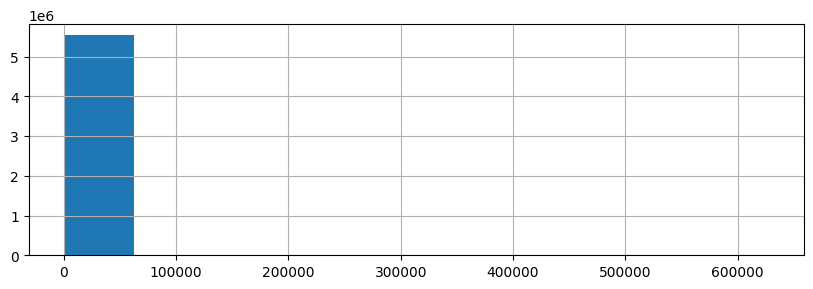

In [21]:
# Histograma
display(df_vendas.faturamento.hist(figsize=(10, 3)))

Tamanho da df filtrada: 1070, 0.00019% dos valores


<Axes: >

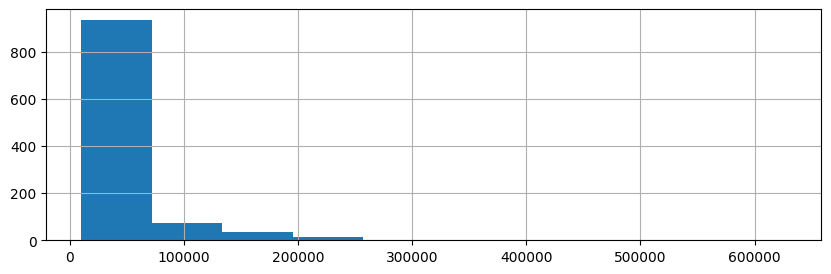

In [22]:
# Linhas a partir de 10000 de faturamento
df_vendas_altos_valores = df_vendas[df_vendas['faturamento'] > 10000]
print(f"Tamanho da df filtrada: {len(df_vendas_altos_valores)}, {np.round(len(df_vendas_altos_valores)/len(df_vendas),5)}% dos valores")

# Histograma dos valores altos
df_vendas_altos_valores['faturamento'].hist(figsize=(10, 3))

In [23]:
# Identificando as lojas com os maiores tickets da base
top_tickets = df_vendas.nlargest(len(df_vendas_altos_valores), 'faturamento')[['codigo_filial', 'faturamento', 'data_emissao']]

# Contando quantas vezes cada loja aparece no Top de faturamento
frequencia_top_lojas = top_tickets['codigo_filial'].value_counts()

print(f"Filiais que mais aparecem nos {len(df_vendas_altos_valores)} tickets extremos:")
display(frequencia_top_lojas.head(10))

Filiais que mais aparecem nos 1070 tickets extremos:


codigo_filial
1848    102
1782     93
1683     81
1761     45
1767     40
1794     38
1884     35
1551     35
1791     34
1851     33
Name: count, dtype: int64

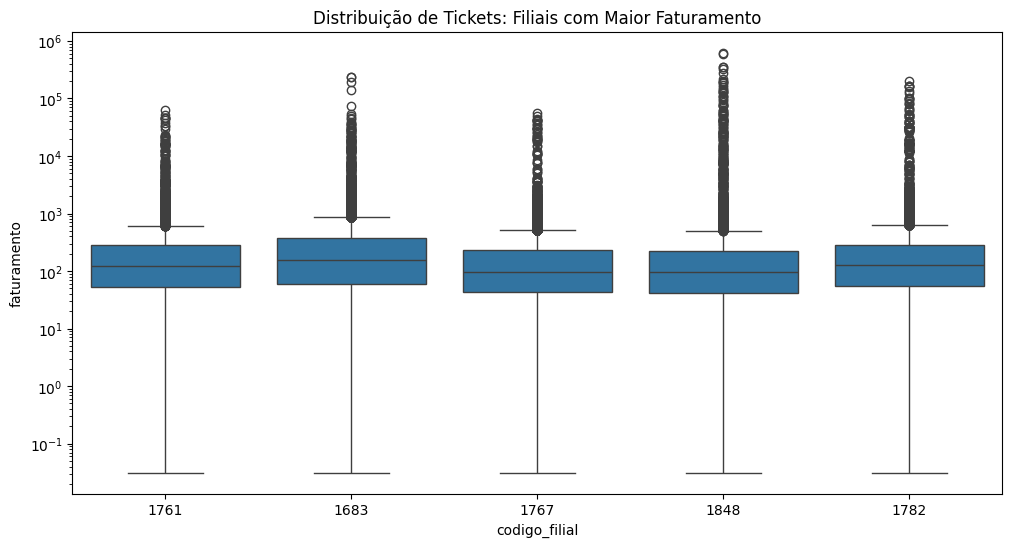

In [24]:
# Top 5 lojas identificadas
top_lojas_ids = frequencia_top_lojas.index[:5]
df_subset = df_vendas[df_vendas['codigo_filial'].isin(top_lojas_ids)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_subset, x='codigo_filial', y='faturamento')
plt.yscale('log') # Escala logarítmica pra conseguir ver os tickets
plt.title('Distribuição de Tickets: Filiais com Maior Faturamento')
plt.show()

In [25]:
# Filtrando o cadastro e exibindo os atributos
perfil_outliers = df_filiais.set_index('codigo_filial').loc[frequencia_top_lojas.index[:10]].reset_index()
display(perfil_outliers[['codigo_filial', 'tipo_estabelecimento', 'localidade', 'metragem_area_venda', 'faixa_vida']])

,codigo_filial,tipo_estabelecimento,localidade,metragem_area_venda,faixa_vida
0,1848,CENTRO,FRANCISCO BELTRAO,450.75,ENTRE 1-2 ANOS
1,1782,CENTRO,ARAPONGAS,585.92,MAIS DE 3 ANOS
2,1683,BAIRRO,UMUARAMA,559.11,MAIS DE 3 ANOS
3,1761,BAIRRO,APUCARANA,503.56,MAIS DE 3 ANOS
4,1767,BAIRRO,LONDRINA,626.68,MAIS DE 3 ANOS
5,1794,CENTRO,GUARAPUAVA,560.68,MAIS DE 3 ANOS
6,1884,MALL,ARAPONGAS,471.28,MENOS DE 1 ANO
7,1551,BAIRRO,CURITIBA,392.50,MAIS DE 3 ANOS
8,1791,CENTRO,FOZ DO IGUACU,495.12,MAIS DE 3 ANOS
9,1851,CENTRO,UMUARAMA,544.00,ENTRE 1-2 ANOS


In [26]:
# Série temporal das 3 lojas com picos de vendas
top_3_lojas = list(frequencia_top_lojas.index[:3]) + ['1698']

df_top3 = df_vendas[df_vendas['codigo_filial'].isin(top_3_lojas)].copy()
df_top3_daily = df_top3.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()
df_top3_daily['codigo_filial'] = df_top3_daily['codigo_filial'].astype(str)

# Gráfico interativo
fig = px.line(
    df_top3_daily,
    x='data_emissao',
    y='faturamento',
    color='codigo_filial',
    title='Faturamento Diário: Dinâmica Temporal das Lojas Top 3',
    labels={
        'data_emissao': 'Data', 
        'faturamento': 'Faturamento Total (R$)', 
        'codigo_filial': 'Filial'
    },
    template='plotly_white'
)

# Slider de tempo interativo na parte inferior
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig.show()

In [27]:
# Definição do grupo de controle (excluindo as Top 15 do ranking de tickets altos)
todas_lojas = df_vendas['codigo_filial'].unique()
top_15_lojas = frequencia_top_lojas.index[:15]
lojas_comuns = [loja for loja in todas_lojas if loja not in top_15_lojas]

# Sorteio de 3 lojas aleatórias para controle
random.seed(42) 
lojas_controle = random.sample(lojas_comuns, 3)
print(f"Lojas de controle sorteadas: {lojas_controle}")

# Filtragem e agregação do faturamento diário para o controle
df_controle = df_vendas[df_vendas['codigo_filial'].isin(lojas_controle)].copy()
df_controle_daily = df_controle.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()
df_controle_daily['codigo_filial'] = df_controle_daily['codigo_filial'].astype(str)

# Gráfico interativo
fig_controle = px.line(
    df_controle_daily,
    x='data_emissao',
    y='faturamento',
    color='codigo_filial',
    title='Faturamento Diário: Grupo de Controle (Lojas Comuns)',
    labels={
        'data_emissao': 'Data', 
        'faturamento': 'Faturamento Total (R$)', 
        'codigo_filial': 'Filial'
    },
    template='plotly_white'
)

# Slider de tempo interativo na parte inferior
fig_controle.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig_controle.show()

Lojas de controle sorteadas: ['1701', '1752', '1704']


In [28]:
# Isolar os registros transacionais da filial anômala
# Definir um limite inferior agressivo (ex: 100k) para filtrar apenas os dias aberrantes
df_investigacao_picos = df_vendas[
    (df_vendas['codigo_filial'] == '1848') & 
    (df_vendas['faturamento'] > 100000)
].copy()

# Agrupar faturamento no nivel diario apenas para os dias onde ocorreram tickets absurdos
df_picos_diarios = df_investigacao_picos.groupby(['codigo_filial', 'data_emissao']).agg(
    faturamento_anomalo=('faturamento', 'sum'),
    quantidade_anomala=('quantidade', 'sum')
).reset_index()

# Padronizar nomes para o cruzamento
df_picos_diarios.rename(columns={'data_emissao': 'data'}, inplace=True)
df_metas.rename(columns={'data_meta_venda': 'data'}, inplace=True)

# Cruzar os dias anomalos com a meta estabelecida pela companhia
validacao_metas = pd.merge(
    df_picos_diarios,
    df_metas[['codigo_filial', 'data', 'meta_n_med']],
    on=['codigo_filial', 'data'],
    how='left'
)

df_metas.rename(columns={'data': 'data_meta_venda'}, inplace=True)

# Criar metrica de desproporcao para avaliar a consciencia do modelo atual sobre o evento
validacao_metas['multiplicador_vs_meta'] = validacao_metas['faturamento_anomalo'] / validacao_metas['meta_n_med']

# Exibir os resultados priorizando as maiores anomalias
display(validacao_metas.sort_values(by='faturamento_anomalo', ascending=False).head(10))

,codigo_filial,data,faturamento_anomalo,quantidade_anomala,meta_n_med,multiplicador_vs_meta
11,1848,2025-11-26,643298.79,8790.00,44779.45,14.37
8,1848,2025-09-30,627414.75,7500.00,30811.16,20.36
3,1848,2025-05-09,591236.71,7440.00,19523.20,30.28
10,1848,2025-11-12,508370.85,4500.00,33477.99,15.19
12,1848,2025-11-28,466336.73,6372.00,95422.90,4.89
5,1848,2025-07-18,459468.62,5700.00,31030.20,14.81
7,1848,2025-09-08,351748.03,4200.00,27332.48,12.87
0,1848,2025-03-06,249833.63,18651.00,20147.37,12.40
4,1848,2025-06-26,241377.68,3078.00,35563.89,6.79
9,1848,2025-10-07,200772.72,2400.00,30366.16,6.61


#### Coluna "quantidade" segue o mesmo padrão

<Axes: >

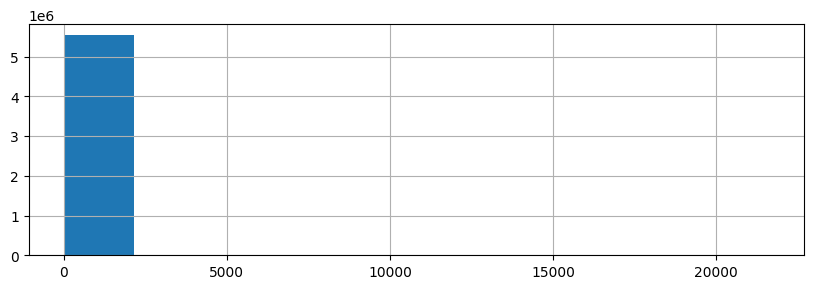

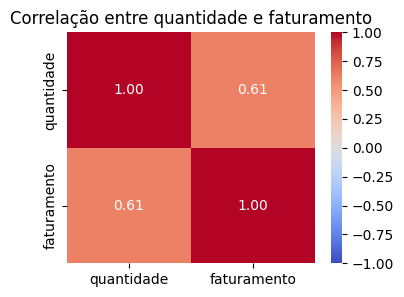

In [29]:
# Coluna de quantidade segue o mesmo padrão
display(df_vendas.quantidade.hist(figsize=(10, 3)))

# Matriz de correlação para as duas colunas
corr_matrix = df_vendas[['quantidade', 'faturamento']].corr()

# Heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title('Correlação entre quantidade e faturamento')
plt.show()

### Metas extremas (0 e 413956.34)

#### Meta 0

- 8% da rede é responsável por 80% das anomalias de meta zero.
- A hipótese inicial era de que esses valores representavam Domingos ou feriados.
- Os dias de meta 0 tem faturamento comum, igual a outros dias. Isso reprova a hipotese de lojas fecharem em Domingos ou feriados. 
- Meta 0 é erro do sistema de metas atual.
- ***Metas em 0 devem ser tratadas como outliers e preenchidas**

In [30]:
# Filtragem de registros com meta zero e extração de metadados temporais
metas_zeradas = df_metas[df_metas['meta_n_med'] == 0].copy()
metas_zeradas['dia_semana'] = metas_zeradas['data_meta_venda'].dt.day_name()
metas_zeradas['mes'] = metas_zeradas['data_meta_venda'].dt.month

# Cruzamento com atributos das filiais para identificar padrões por perfil
metas_zeradas_perfil = metas_zeradas.merge(df_filiais, on='codigo_filial', how='left')

# Análise de concentração de metas zero
print("Distribuição por Dia da Semana:")
display(metas_zeradas['dia_semana'].value_counts())

print("\nTop 10 Filiais com mais metas zeradas:")
display(metas_zeradas['codigo_filial'].value_counts().head(10))

# Tipo de estabelecimento
print("\nDistribuição por Tipo de Estabelecimento:")
display(metas_zeradas_perfil['tipo_estabelecimento'].value_counts())
print(f"Padrão de distribuição em df_filiais:")
display(df_filiais['tipo_estabelecimento'].value_counts())

Distribuição por Dia da Semana:


dia_semana
Sunday       412
Thursday      54
Wednesday     40
Saturday      33
Monday        32
Friday        28
Tuesday       28
Name: count, dtype: int64


Top 10 Filiais com mais metas zeradas:


codigo_filial
1500    63
1548    62
1509    62
1749    62
1578    57
1590    54
1734    49
1860    31
1875    31
1872    31
Name: count, dtype: int64


Distribuição por Tipo de Estabelecimento:


tipo_estabelecimento
BAIRRO          343
CENTRO          273
SHOPPING          7
SUPERMERCADO      4
Name: count, dtype: int64

Padrão de distribuição em df_filiais:


tipo_estabelecimento
BAIRRO          76
CENTRO          38
SHOPPING         6
MALL             3
SUPERMERCADO     1
Name: count, dtype: int64

In [31]:
# Gráfico de pareto para análise de filiais com meta 0
# Filtragem de registros com meta estritamente igual a zero
df_metas_zeradas = df_metas[df_metas['meta_n_med'] == 0].copy()

# Contagem de frequência por filial e ordenação decrescente (regra do Pareto)
df_pareto = df_metas_zeradas['codigo_filial'].value_counts().reset_index()
df_pareto.columns = ['codigo_filial', 'qtd_metas_zeradas']
df_pareto['codigo_filial'] = df_pareto['codigo_filial'].astype(str)

# Cálculo da porcentagem acumulada para a linha do gráfico
total_zeradas = df_pareto['qtd_metas_zeradas'].sum()
df_pareto['perc_acumulada'] = (df_pareto['qtd_metas_zeradas'].cumsum() / total_zeradas) * 100

# Construção da figura com eixo Y secundário (Eixo Esquerdo: Contagem | Eixo Direito: %)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adição das barras (Volume absoluto)
fig.add_trace(
    go.Bar(
        x=df_pareto['codigo_filial'],
        y=df_pareto['qtd_metas_zeradas'],
        name="Dias com Meta Zero",
        marker_color="lightslategray"
    ),
    secondary_y=False,
)

# Adição da linha (Curva de Pareto)
fig.add_trace(
    go.Scatter(
        x=df_pareto['codigo_filial'],
        y=df_pareto['perc_acumulada'],
        name="% Acumulada",
        mode="lines+markers",
        line=dict(color="crimson", width=2),
        marker=dict(size=6)
    ),
    secondary_y=True,
)

# Ajustes visuais e de layout
fig.update_layout(
    title_text="Análise de Pareto: Concentração de Metas Zeradas por Filial",
    template="plotly_white",
    hovermode="x unified",
    showlegend=False,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.update_yaxes(title_text="Frequência (Dias)", secondary_y=False)
fig.update_yaxes(title_text="Percentual Acumulado (%)", range=[0, 105], secondary_y=True)
fig.update_xaxes(type='category', title_text="Código da Filial")

fig.show()

In [32]:
# Dos dias de meta 0, quantos tiveram faturamento?

# Agregação Diária por Filial garante a análise do faturamento diário total de cada loja
df_diario_loja = df_vendas.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()

# Padronização de tipos e normalização para garantir a integridade do merge
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda']).dt.normalize()

# Consolidação da base de performance para comparação direta entre realizado e planejado
df_performance = pd.merge(
    df_diario_loja,
    df_metas,
    left_on=['data_emissao', 'codigo_filial'],
    right_on=['data_meta_venda', 'codigo_filial'],
    how='inner'
)

# Isolamento das ocorrências com Meta 0
df_meta_zero = df_performance[df_performance['meta_n_med'] == 0].copy()

# Classificação booleana de faturamento realizado
df_meta_zero['teve_faturamento'] = df_meta_zero['faturamento'] > 0

# Sumarização quantitativa das ocorrências
resumo_meta_zero = df_meta_zero['teve_faturamento'].value_counts().to_frame('quantidade_dias')
resumo_meta_zero['percentual'] = (resumo_meta_zero['quantidade_dias'] / resumo_meta_zero['quantidade_dias'].sum()) * 100

print("Análise de dias com Meta 0:")
print(resumo_meta_zero)

# Visão do faturamento total gerado nesses dias não planejados
faturamento_inesperado = df_meta_zero[df_meta_zero['teve_faturamento']]['faturamento'].sum()
print(f"\nFaturamento total acumulado em dias de Meta 0: R$ {faturamento_inesperado:,.2f}")

Análise de dias com Meta 0:
                  quantidade_dias  percentual
teve_faturamento                             
True                          139      100.00

Faturamento total acumulado em dias de Meta 0: R$ 1,615,140.87


In [33]:
# Os faturamentos dos dias de Meta 0 são relevantes?

# Análise estatística descritiva dos valores faturados quando a meta era zero
stats_meta_zero = df_meta_zero[df_meta_zero['teve_faturamento']]['faturamento'].describe()

# Cálculo do faturamento mediano em dias com meta positiva para servir de baseline
mediana_planejada = df_performance[df_performance['meta_n_med'] > 0]['faturamento'].median()

print("Distribuição do faturamento real em dias de Meta 0:")
print(stats_meta_zero.to_frame())

print(f"\nFaturamento mediano em dias planejados (Baseline de normalidade): R$ {mediana_planejada:,.2f}")

# Identificação de representatividade: quantos casos superam 50% do faturamento de um dia normal
casos_relevantes = df_meta_zero[df_meta_zero['faturamento'] > (mediana_planejada * 0.5)].shape[0]
print(f"Ocorrências com faturamento superior a 50% de um dia normal: {casos_relevantes}")

Distribuição do faturamento real em dias de Meta 0:
       faturamento
count       139.00
mean      11619.72
std       11127.31
min           1.82
25%        5571.91
50%       10443.61
75%       15925.26
max      101078.29

Faturamento mediano em dias planejados (Baseline de normalidade): R$ 22,338.35
Ocorrências com faturamento superior a 50% de um dia normal: 65


#### Meta alta
- A meta alta NÃO é um erro, é indício de um faturamento alto previsível.
- dia 28/11/2025 foi Black Friday.
- A loja 1521 tem as maiores metas diárias, principalmente no mês de novembro (Black november ou algo parecido?)

In [34]:
# Isolamento da meta máxima
top_meta = df_metas.nlargest(300, 'meta_n_med').copy()

# Agregação das vendas reais do dia correspondente
df_vendas_dia = df_vendas.groupby(['codigo_filial', 'data_emissao'])['faturamento'].sum().reset_index()

# Cruzamento para obter o Realizado vs Planejado
diagnostico_max = top_meta.merge(
    df_vendas_dia, 
    left_on=['codigo_filial', 'data_meta_venda'], 
    right_on=['codigo_filial', 'data_emissao'], 
    how='left'
)

# Adição do contexto da loja
diagnostico_max = diagnostico_max.merge(df_filiais, on='codigo_filial', how='left')

# Cálculo de erro do planejamento
diagnostico_max['desvio_percentual'] = (diagnostico_max['faturamento'] / diagnostico_max['meta_n_med']) - 1

display(diagnostico_max[['codigo_filial', 'data_meta_venda', 'meta_n_med', 'faturamento', 'desvio_percentual', 'tipo_estabelecimento', 'localidade']].head(10))

,codigo_filial,data_meta_venda,meta_n_med,faturamento,desvio_percentual,tipo_estabelecimento,localidade
0,1521,2025-11-28,413956.34,524639.91,0.27,BAIRRO,CURITIBA
1,1521,2025-11-24,320274.57,505024.71,0.58,BAIRRO,CURITIBA
2,1521,2025-11-25,303294.74,460715.97,0.52,BAIRRO,CURITIBA
3,1521,2025-11-27,293341.06,534059.77,0.82,BAIRRO,CURITIBA
4,1521,2025-11-26,282216.35,407213.00,0.44,BAIRRO,CURITIBA
5,1521,2025-04-16,235570.78,142158.77,-0.40,BAIRRO,CURITIBA
6,1521,2025-12-22,234420.63,150366.49,-0.36,BAIRRO,CURITIBA
7,1521,2025-11-06,234204.44,157010.27,-0.33,BAIRRO,CURITIBA
8,1521,2025-11-04,231276.89,164462.29,-0.29,BAIRRO,CURITIBA
9,1521,2025-11-05,224250.76,164254.95,-0.27,BAIRRO,CURITIBA


In [35]:
diagnostico_max[(diagnostico_max['data_emissao'].dt.month != 11) & (diagnostico_max['codigo_filial'] != "1521")]

,codigo_filial,data_meta_venda,meta_n_med,data_emissao,faturamento,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,desvio_percentual
97,1698,2025-12-20,160710.60,2025-12-20,184773.09,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,0.15
200,1698,2025-12-27,144702.32,2025-12-27,172870.84,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,0.19
255,1698,2025-12-13,129007.94,2025-12-13,146291.89,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,0.13
259,1698,2025-12-26,126810.72,2025-12-26,205947.96,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,0.62
280,1698,2025-12-19,121788.51,2025-12-19,155142.25,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,0.27
299,1698,2025-12-06,118963.52,2025-12-06,105327.97,MAIS DE 3 ANOS,CURITIBA,PR,SHOPPING,NÃO,571.48,SIM,SIM,NÃO,-0.11


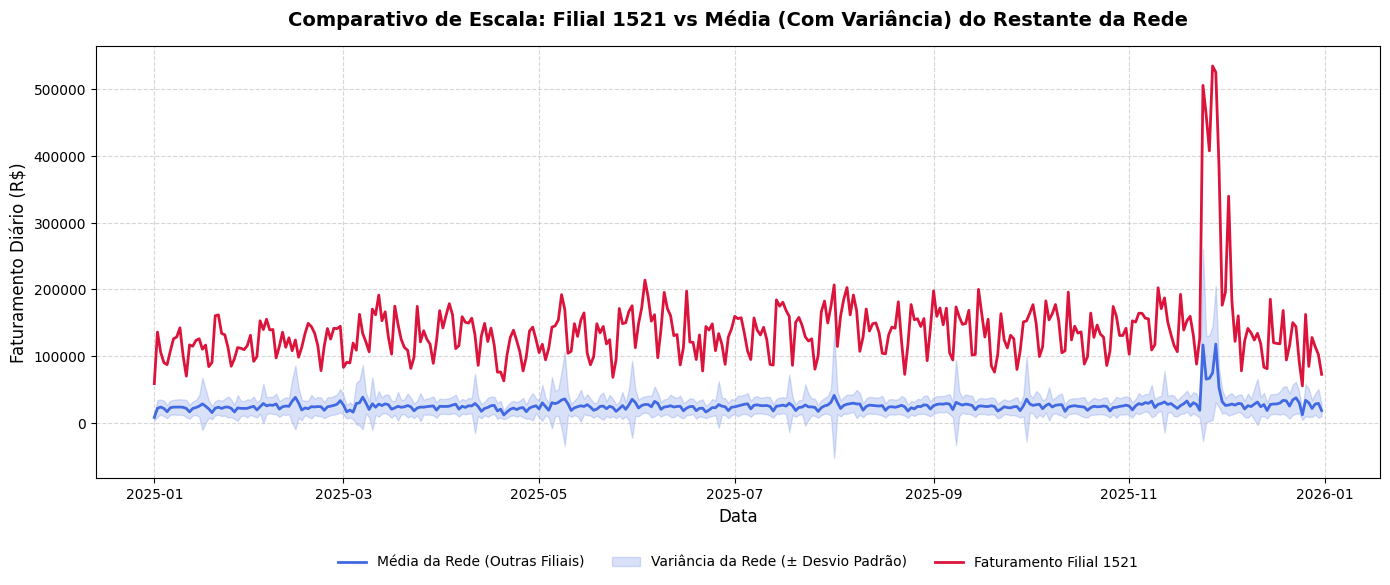

In [36]:
# Gráfico comparativo da média de faturamento das filiais diariamente e da 1521
# Seaborn pra não explodir a RAM

# Tipagem
df_vendas['codigo_filial'] = df_vendas['codigo_filial'].astype(str)

# Agregação Diária por Filial garante a análise do faturamento diário total de cada loja
df_diario_loja = df_vendas.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()

# Separação e ordenação das bases
df_1521 = df_diario_loja[df_diario_loja['codigo_filial'] == '1521'].copy()
df_1521 = df_1521.sort_values('data_emissao')

df_outras = df_diario_loja[df_diario_loja['codigo_filial'] != '1521'].copy()

# Pré-cálculo da Média e Variância do restante da rede
df_outras_agg = df_outras.groupby('data_emissao')['faturamento'].agg(['mean', 'std']).reset_index()
df_outras_agg = df_outras_agg.sort_values('data_emissao')

# Configuração do Gráfico em Eixo Único
fig, ax = plt.subplots(figsize=(14, 6))

# Plot da Média da Rede
ax.plot(
    df_outras_agg['data_emissao'], 
    df_outras_agg['mean'], 
    color='royalblue', 
    linewidth=2, 
    label='Média da Rede (Outras Filiais)'
)

# Plot da Margem de Variância em vetor otimiza o consumo de RAM
ax.fill_between(
    df_outras_agg['data_emissao'],
    df_outras_agg['mean'] - df_outras_agg['std'],
    df_outras_agg['mean'] + df_outras_agg['std'],
    color='royalblue',
    alpha=0.2,
    label='Variância da Rede (± Desvio Padrão)'
)

# Plot da Filial 1521 no mesmo espaço contínuo de tempo
ax.plot(
    df_1521['data_emissao'], 
    df_1521['faturamento'], 
    color='crimson', 
    linewidth=2, 
    label='Faturamento Filial 1521'
)

# Ajustes Visuais
ax.set_title('Comparativo de Escala: Filial 1521 vs Média (Com Variância) do Restante da Rede', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Faturamento Diário (R$)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

## Análise de sazonalidade

### Feriados
- Black friday aumenta o faturamento de forma extraordinária, quase mágica.
- A maioria dos feriados reduz o faturamento
- ***Vamos manter os feriados como features**
- Impacto médio dos feriados é, na média, irrelevante (1.06%).
- Existem feriados que impulsionam e feriados que freiam o faturamento

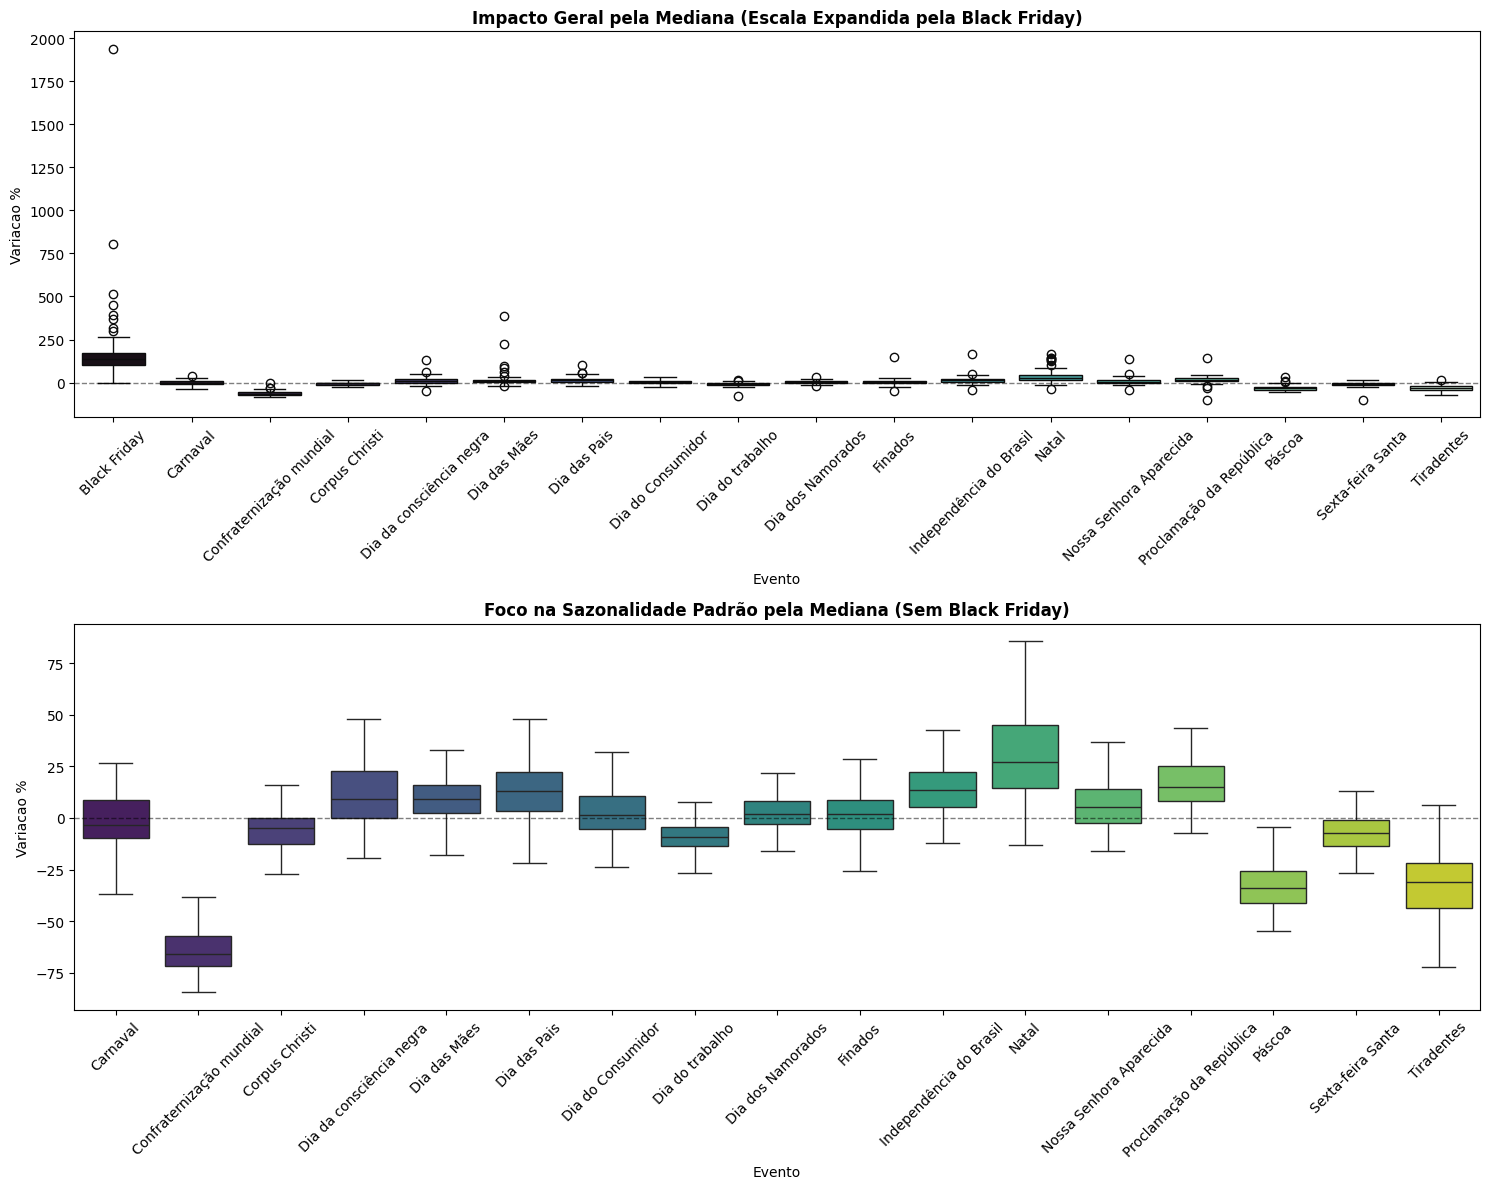

In [37]:
# Filtrar as datas correspondentes a eventos oficiais no calendário
df_calendario['data'] = pd.to_datetime(df_calendario['data'])
feriados = df_calendario[df_calendario['evento'].notna() & (df_calendario['evento'] != 'Dia Comum')].copy()

# Expandir o calendário para criar a janela de antecipação de compras
datas_expandidas = []
for _, row in feriados.iterrows():
    evento = row['evento']
    data_feriado = row['data']
    
    # Adicionar o dia do evento e retroagir 6 dias para compor a janela de 7 dias de impacto
    for i in range(7): 
        datas_expandidas.append({
            'data': data_feriado - pd.Timedelta(days=i),
            'evento': evento
        })

# Consolidar as datas expandidas e remover sobreposições de eventos
df_calendario_expandido = pd.DataFrame(datas_expandidas).drop_duplicates(subset=['data'], keep='first')

# Cruzar o faturamento diário com o calendário expandido
df_sazonal = pd.merge(
    df_diario_loja, 
    df_calendario_expandido, 
    left_on='data_emissao', 
    right_on='data', 
    how='left'
)

# Preencher dias sem influência de eventos com a categoria padrão
df_sazonal['evento'] = df_sazonal['evento'].fillna('Dia Comum')

# Agrupar a mediana de faturamento por filial e isolar o baseline diário
stats = df_sazonal.groupby(['codigo_filial', 'evento'])['faturamento'].median().unstack()
stats['mediana_comum'] = stats['Dia Comum']

# Calcular o delta percentual de performance dos eventos contra o baseline
eventos_lista = [c for c in stats.columns if c not in ['Dia Comum', 'mediana_comum']]
for ev in eventos_lista:
    stats[f'delta_{ev}'] = ((stats[ev] - stats['mediana_comum']) / stats['mediana_comum']) * 100

# Isolar os impactos para compor a métrica de sensibilidade sem a distorção de eventos atípicos
deltas_cols = [f'delta_{ev}' for ev in eventos_lista]
deltas_sem_bf = [c for c in deltas_cols if 'Black Friday' not in c]

# Calcular a mediana de oscilação para os feriados padrão
stats['sensibilidade_sem_bf'] = stats[deltas_sem_bf].median(axis=1)

# Transformar o formato dos dados para otimização da plotagem gráfica
df_melted = stats[deltas_cols].melt(var_name='Evento', value_name='Variacao %')
df_melted['Evento'] = df_melted['Evento'].str.replace('delta_', '')

# Construir a estrutura visual para os comparativos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Renderizar gráfico com escala expandida para evidenciar outliers extremos
sns.boxplot(data=df_melted, x='Evento', y='Variacao %', ax=ax1, palette='mako', hue='Evento', legend=False)
ax1.set_title('Impacto Geral pela Mediana (Escala Expandida pela Black Friday)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Renderizar gráfico com foco na variação típica sazonal
sns.boxplot(data=df_melted[df_melted['Evento'] != 'Black Friday'], x='Evento', y='Variacao %', ax=ax2, palette='viridis', showfliers=False, hue='Evento', legend=False)
ax2.set_title('Foco na Sazonalidade Padrão pela Mediana (Sem Black Friday)', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# Inserir linhas de referência
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

In [38]:
# Calcular a mediana global da rede para medir o desvio padrão de cada filial
norma_rede = stats['sensibilidade_sem_bf'].median()

# Consolidar métricas calculadas com os atributos estruturais das filiais
df_final = stats[['sensibilidade_sem_bf']].merge(df_filiais, on='codigo_filial')
df_final['desvio_da_norma'] = df_final['sensibilidade_sem_bf'] - norma_rede

# Extrair as partições de vulnerabilidade e resiliência
lojas_vulneraveis = df_final.sort_values(by='sensibilidade_sem_bf', ascending=True).head(10)
lojas_resilientes = df_final.sort_values(by='sensibilidade_sem_bf', ascending=False).head(10)

# Exibir os resultados analíticos
print(f"Impacto Mediano Geral da Rede (Normalidade): {norma_rede:.2f}%\n")

print("Filiais com MAIOR vulnerabilidade sazonal (Maiores quedas medianas):")
display(lojas_vulneraveis[['codigo_filial', 'tipo_estabelecimento', 'localidade', 'sensibilidade_sem_bf', 'desvio_da_norma']])

print("\nFiliais com MAIOR resiliência/crescimento sazonal (Maiores ganhos medianos):")
display(lojas_resilientes[['codigo_filial', 'tipo_estabelecimento', 'localidade', 'sensibilidade_sem_bf', 'desvio_da_norma']])

Impacto Mediano Geral da Rede (Normalidade): 1.06%

Filiais com MAIOR vulnerabilidade sazonal (Maiores quedas medianas):


,codigo_filial,tipo_estabelecimento,localidade,sensibilidade_sem_bf,desvio_da_norma
37,1617,BAIRRO,LONDRINA,-17.82,-18.88
60,1695,BAIRRO,PATO BRANCO,-11.78,-12.83
9,1527,BAIRRO,CURITIBA,-8.18,-9.24
35,1611,BAIRRO,LONDRINA,-7.24,-8.29
58,1689,BAIRRO,LONDRINA,-6.83,-7.89
78,1752,CENTRO,FOZ DO IGUACU,-6.51,-7.57
80,1758,CENTRO,LONDRINA,-5.47,-6.52
63,1707,CENTRO,CASCAVEL,-5.45,-6.51
51,1665,CENTRO,CASCAVEL,-5.29,-6.34
91,1791,CENTRO,FOZ DO IGUACU,-4.25,-5.31



Filiais com MAIOR resiliência/crescimento sazonal (Maiores ganhos medianos):


,codigo_filial,tipo_estabelecimento,localidade,sensibilidade_sem_bf,desvio_da_norma
123,1887,SUPERMERCADO,MARINGA,33.40,32.35
119,1875,BAIRRO,MARINGA,25.42,24.37
115,1863,CENTRO,CASCAVEL,24.84,23.78
120,1878,BAIRRO,CURITIBA,16.84,15.78
118,1872,BAIRRO,GOIOERE,16.31,15.25
117,1869,CENTRO,TELEMACO BORBA,13.18,12.13
77,1749,BAIRRO,CURITIBA,11.91,10.86
81,1761,BAIRRO,APUCARANA,10.52,9.46
112,1854,BAIRRO,CAMPO MOURAO,10.41,9.35
116,1866,CENTRO,SAO JOSE DOS PINHAIS,9.22,8.17


In [39]:
print(df_final[df_final['codigo_filial']=='1848'])

    codigo_filial  sensibilidade_sem_bf      faixa_vida         localidade  \
110          1848                  0.18  ENTRE 1-2 ANOS  FRANCISCO BELTRAO   

     uf tipo_estabelecimento delivery  metragem_area_venda panvel_clinic  \
110  PR               CENTRO      NÃO               450.75           NÃO   

    estacionamento atendimento_24_horas  desvio_da_norma  
110            SIM                  NÃO            -0.87  


### Padrão semanal
- Shopping tem um pico no sábado.
- Supermercado é constante, mas fatura pouco.
- Perfil do Centro é parecido com o do Bairro
- Variância do Mall é a maior de todas

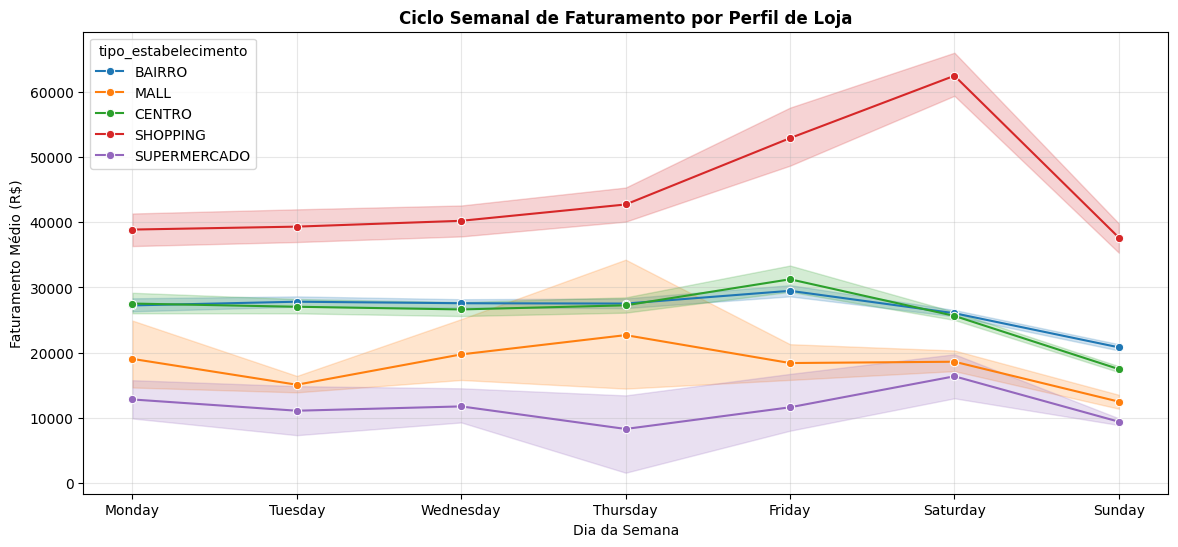

In [40]:
# Garantia de tipagem e normalização para o merge
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda']).dt.normalize()

# Definição do ciclo semanal ordenado
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_performance['dia_semana'] = pd.Categorical(
    df_performance['data_emissao'].dt.day_name(), 
    categories=ordem_dias, 
    ordered=True
)

df_performance['atingimento'] = (df_performance['faturamento'] / df_performance['meta_n_med']) * 100

# Integração com perfil para visualização
df_semanal_perfil = df_performance.merge(df_filiais[['codigo_filial', 'tipo_estabelecimento']], on='codigo_filial')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_semanal_perfil,
    x='dia_semana',
    y='faturamento',
    hue='tipo_estabelecimento',
    marker='o',
    estimator='mean'
)
plt.title('Ciclo Semanal de Faturamento por Perfil de Loja', fontweight='bold')
plt.ylabel('Faturamento Médio (R$)')
plt.xlabel('Dia da Semana')
plt.grid(True, alpha=0.3)
plt.show()

### Padrão mensal
- A hipotese inicial era de que o dia de maior liquidez seria no início do mês, próximo ao quinto dia util
- A maioria dos estabelecimentos tem um pico no final do mês, especificamente a partir do dia 24.
- Leve pico de Shoppings no início do mês
- Supermercados não tem dados do dia 1 ao 4

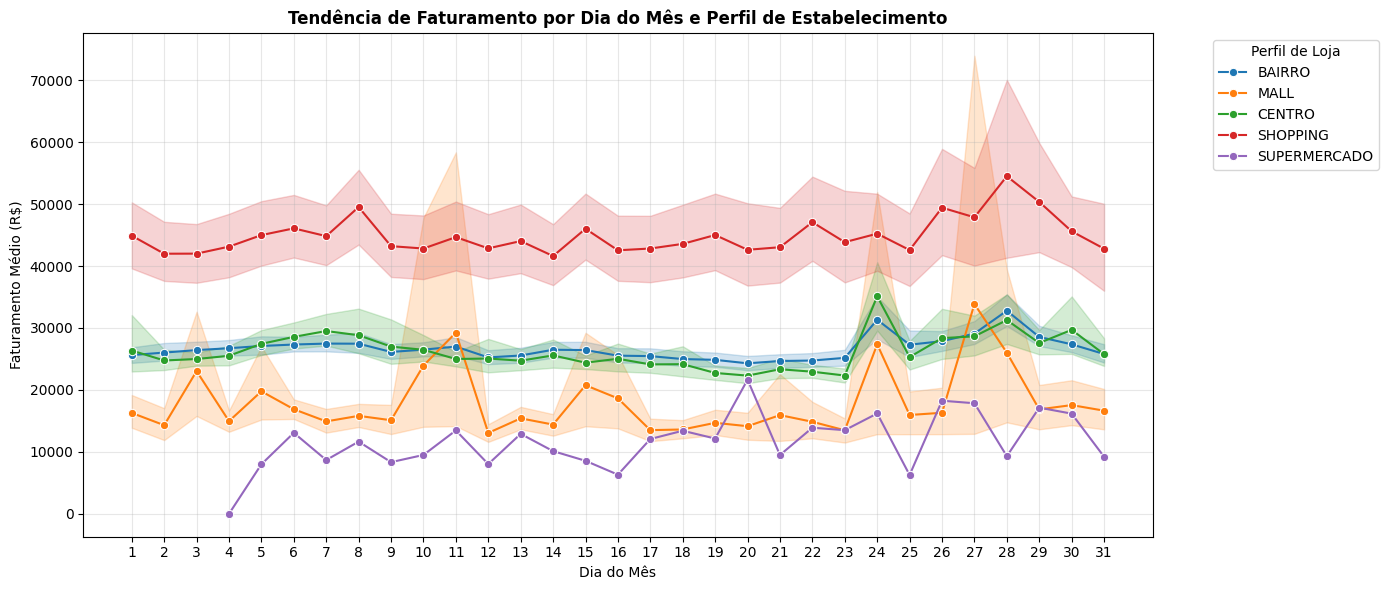

In [41]:
# Padronização de tipos e normalização temporal para garantir a integridade do cruzamento
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda']).dt.normalize()

# Extração da posição cronológica dentro do mês para análise de sazonalidade de pagamento
df_performance['dia_mes'] = df_performance['data_emissao'].dt.day

# Cálculo do indicador de eficiência para diagnóstico de desvios operacionais
df_performance['atingimento'] = (df_performance['faturamento'] / df_performance['meta_n_med']) * 100

# Enriquecimento da base com os atributos qualitativos das filiais
df_diario_perfil = df_performance.merge(df_filiais[['codigo_filial', 'tipo_estabelecimento']], on='codigo_filial')

# Configuração gráfica para visualização da tendência média de faturamento por dia do mês
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_diario_perfil,
    x='dia_mes',
    y='faturamento',
    hue='tipo_estabelecimento',
    marker='o',
    estimator='mean'
)

# Ajustes visuais para garantir a interpretabilidade da escala temporal mensal
plt.title('Tendência de Faturamento por Dia do Mês e Perfil de Estabelecimento', fontweight='bold')
plt.ylabel('Faturamento Médio (R$)')
plt.xlabel('Dia do Mês')
plt.xticks(range(1, 32))
plt.grid(True, alpha=0.3)

# Posicionamento da legenda para evitar obstrução dos dados
plt.legend(title='Perfil de Loja', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Dias faltantes
- Muitas filiais com muitos dias faltantes.
- O interessante seria investigar de forma mais aprofundada se isso é um erro ou padrão individual de abrir apenas alguns dias.
    - Possivelmente lojas que fecharam ou abriram no meio do ano.
- Por enquanto, vão ser desconsideradas todas que tenham mais de 70 dias faltantes.
    - Motivo: os valores que apresentam 69 ou menos podem ser referentes a Domingos e Feriados.
    - Como foi visto antes, Domingos de meta 0 ainda faturam normalmente.
- ***Filiais acima de 70 dias faltantes: Descarte da filial no modelo final**
- ***Filiais abaixo de 70 dias faltantes: Fill**
- ***Preenchimento de dias faltantes da filiais, considerando mediana dos dias passados (prioridade para o mesmo dia da semana)**

In [42]:
# Filtro seco: Lojas de Supermercado nos dias 1 a 4
df_super_gap = df_diario_perfil[
    (df_diario_perfil['tipo_estabelecimento'] == 'SUPERMERCADO') & 
    (df_diario_perfil['dia_mes'] <= 4)
].copy()

# Verificação de volume de registros por dia do mês
contagem_por_dia = df_super_gap.groupby('dia_mes').size().to_frame('qtd_registros')
faturamento_por_dia = df_super_gap.groupby('dia_mes')['faturamento'].sum().to_frame('faturamento_total')

print("Análise de Volume: Supermercados (Dias 1 a 4)")
print(contagem_por_dia.join(faturamento_por_dia))

Análise de Volume: Supermercados (Dias 1 a 4)
         qtd_registros  faturamento_total
dia_mes                                  
4                    1               5.47


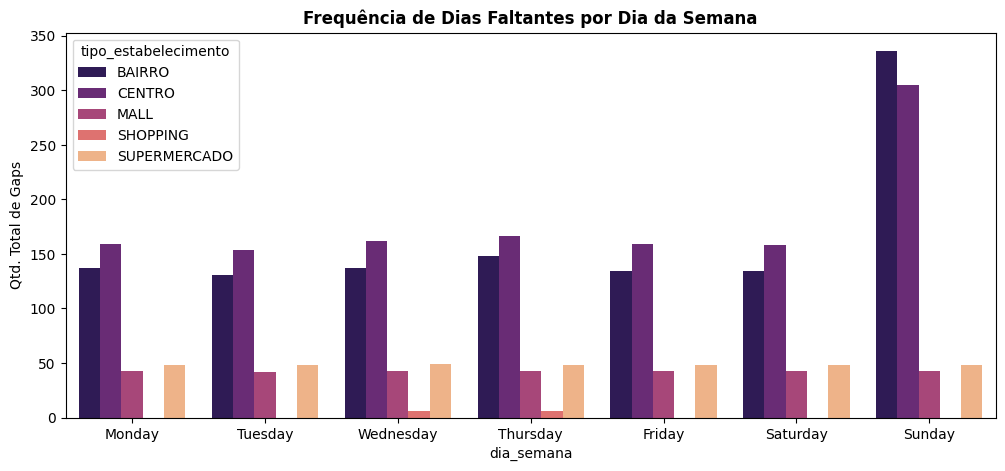

In [43]:
# Criação do Calendário Completo (Spine)
data_min = df_diario_loja['data_emissao'].min()
data_max = df_diario_loja['data_emissao'].max()
todas_as_datas = pd.date_range(start=data_min, end=data_max, freq='D')

todas_as_filiais = df_filiais['codigo_filial'].unique()

# Criamos o produto cartesiano para garantir que toda loja tenha todas as datas
index_completo = pd.MultiIndex.from_product(
    [todas_as_datas, todas_as_filiais], 
    names=['data_emissao', 'codigo_filial']
)
df_gap_analise = pd.DataFrame(index=index_completo).reset_index()

# Cruzamento para identificar buracos (NaN no faturamento)
df_gap_analise = pd.merge(
    df_gap_analise, 
    df_diario_loja[['data_emissao', 'codigo_filial', 'faturamento']], 
    on=['data_emissao', 'codigo_filial'], 
    how='left'
)

# Flag de dia faltante
df_gap_analise['is_faltante'] = df_gap_analise['faturamento'].isna().astype(int)

# Enriquecimento com perfil da loja e Dia da Semana
df_gap_analise = df_gap_analise.merge(
    df_filiais[['codigo_filial', 'tipo_estabelecimento']], 
    on='codigo_filial'
)

# Definimos a ordem lógica da semana (removido dia_mes daqui)
df_gap_analise['dia_semana'] = pd.Categorical(
    df_gap_analise['data_emissao'].dt.day_name(),
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

# --- VISUALIZAÇÕES ---
plt.figure(figsize=(12, 5))
gap_semanal = df_gap_analise.groupby(['dia_semana', 'tipo_estabelecimento'], observed=False)['is_faltante'].sum().reset_index()

# Gráfico focado apenas na sazonalidade semanal dos gaps
sns.barplot(data=gap_semanal, x='dia_semana', y='is_faltante', hue='tipo_estabelecimento', palette='magma')
plt.title('Frequência de Dias Faltantes por Dia da Semana', fontweight='bold')
plt.ylabel('Qtd. Total de Gaps')
plt.show()

In [44]:
a = df_gap_analise.groupby(['codigo_filial', 'tipo_estabelecimento'])['is_faltante'].sum().reset_index()
a[a['tipo_estabelecimento']=='SUPERMERCADO']

,codigo_filial,tipo_estabelecimento,is_faltante
123,1887,SUPERMERCADO,337


In [45]:
# Ranking das filiais mais "problemáticas"
print("Top 15 Filiais com maior quantidade de dias faltantes:")
ranking_gaps = df_gap_analise.groupby(['codigo_filial', 'tipo_estabelecimento'])['is_faltante'].sum().nlargest(15).reset_index()
display(ranking_gaps)

# Filtro
filiais_drop = ranking_gaps[ranking_gaps['is_faltante']>70].codigo_filial.to_list()

Top 15 Filiais com maior quantidade de dias faltantes:


,codigo_filial,tipo_estabelecimento,is_faltante
0,1887,SUPERMERCADO,337
1,1872,BAIRRO,320
2,1884,MALL,300
3,1875,BAIRRO,289
4,1866,CENTRO,266
5,1881,CENTRO,232
6,1869,CENTRO,205
7,1878,BAIRRO,202
8,1863,CENTRO,174
9,1860,CENTRO,147


### Padrão de atingimento de metas
- Shoppings batem a meta com frequência
- As novas metas deverão ser otimizadas a fim de maximizar o lucro, considerando fatores como:
    - Motivação do time (manter o time motivado)
    - Possibilidade máxima de lucro
    - Equilibrio entre meta conservadora e arrojada

In [46]:
# O quanto o perfil de estabelecimento influencia no atingimento das metas?
# Padronização de tipos
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda']).dt.normalize()

# Tratamento de divisão por zero: removemos dias com meta zero para não gerar 'inf'
# Dias com meta zero e faturamento > 0 indicam abertura não planejada ou erro de cadastro de meta
df_valid_meta = df_performance[df_performance['meta_n_med'] > 0].copy()

# Cálculo do atingimento real sobre metas válidas
df_valid_meta['atingimento_pct'] = (df_valid_meta['faturamento'] / df_valid_meta['meta_n_med']) * 100

# Integração com atributos qualitativos
df_ranking_limpo = df_valid_meta.merge(
    df_filiais[['codigo_filial', 'tipo_estabelecimento', 'localidade']], 
    on='codigo_filial'
)

# Recálculo das visões de ranking sem a distorção do infinito
ranking_consolidado = df_ranking_limpo.groupby(['codigo_filial', 'tipo_estabelecimento', 'localidade'])['atingimento_pct'].mean().reset_index()

print("Filiais com metas mais agressivas (Menor atingimento real):")
display(ranking_consolidado.sort_values('atingimento_pct', ascending=True).head(10))

print("\nFiliais com metas mais conservadoras (Maior atingimento real, excluindo erros de meta zero):")
display(ranking_consolidado.sort_values('atingimento_pct', ascending=False).head(10))

Filiais com metas mais agressivas (Menor atingimento real):


,codigo_filial,tipo_estabelecimento,localidade,atingimento_pct
118,1875,BAIRRO,MARINGA,76.80
117,1869,CENTRO,TELEMACO BORBA,79.63
28,1590,BAIRRO,LONDRINA,79.69
19,1560,BAIRRO,CURITIBA,80.00
44,1644,BAIRRO,CURITIBA,82.15
30,1596,BAIRRO,CURITIBA,82.22
13,1542,BAIRRO,CURITIBA,85.13
108,1842,BAIRRO,CURITIBA,85.21
3,1509,CENTRO,CURITIBA,85.98
10,1530,BAIRRO,CURITIBA,86.32



Filiais com metas mais conservadoras (Maior atingimento real, excluindo erros de meta zero):


,codigo_filial,tipo_estabelecimento,localidade,atingimento_pct
121,1884,MALL,ARAPONGAS,176.64
110,1848,CENTRO,FRANCISCO BELTRAO,135.02
88,1782,CENTRO,ARAPONGAS,122.95
116,1866,CENTRO,SAO JOSE DOS PINHAIS,118.50
105,1833,BAIRRO,COLOMBO,115.67
45,1647,SHOPPING,SAO JOSE DOS PINHAIS,114.83
106,1836,CENTRO,MEDIANEIRA,113.86
61,1698,SHOPPING,CURITIBA,113.01
58,1689,BAIRRO,LONDRINA,111.47
75,1743,CENTRO,TOLEDO,111.33


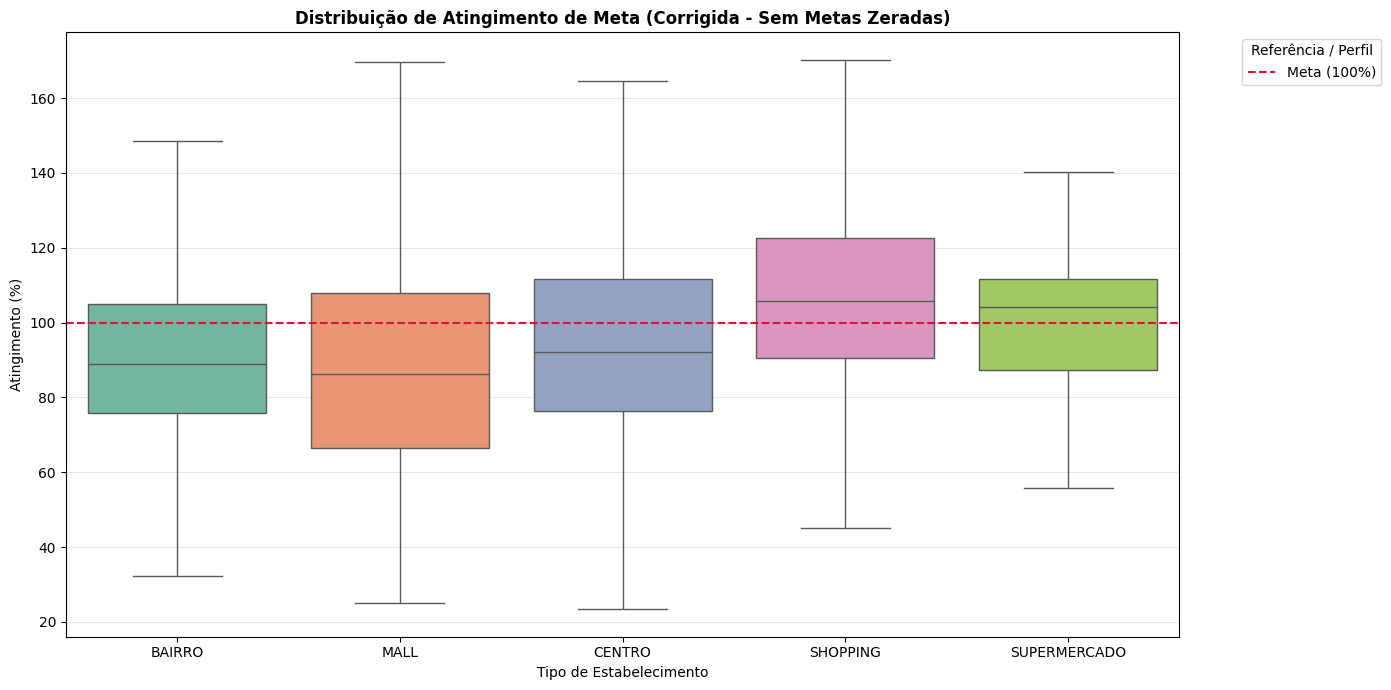

In [47]:
# Visualização da distribuição de atingimento corrigida
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_ranking_limpo, 
    x='tipo_estabelecimento', 
    y='atingimento_pct', 
    hue='tipo_estabelecimento',
    palette='Set2',
    showfliers=False
)
plt.axhline(100, color='crimson', linestyle='--', linewidth=1.5, label='Meta (100%)')
plt.legend(title='Referência / Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Distribuição de Atingimento de Meta (Corrigida - Sem Metas Zeradas)', fontweight='bold')
plt.ylabel('Atingimento (%)')
plt.xlabel('Tipo de Estabelecimento')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## ===================================

## Limpeza dos dados
- Limpeza a partir de todas as inconsistências encontradas anteriormente (marcadas com *)

### Criação de datas faltantes
- Criamos entradas para as datas que estavam faltando. 
- df_vendas ficou com fillna(0)
- df_metas continua com NaNs e 0s, porque significam coisas diferentes ainda.

In [48]:
# Filtragem de escopo: isola apenas as filiais ativas para o processamento
filiais_validas = df_filiais[df_filiais['codigo_filial'] != '1704']['codigo_filial'].astype(str).unique()
todas_as_datas = pd.to_datetime(todas_as_datas)

# Construção da Malha Cronológica (Grid): garante que todos os dias existam para todas as filiais
df_grid = pd.MultiIndex.from_product(
    [filiais_validas, todas_as_datas],
    names=['codigo_filial', 'data']
).to_frame(index=False)

# Padronização de tipos e nomes de colunas para viabilizar os cruzamentos (Merge)
df_vendas['codigo_filial'] = df_vendas['codigo_filial'].astype(str)
df_vendas.rename(columns={'data_emissao': 'data'}, inplace=True)
df_vendas['data'] = pd.to_datetime(df_vendas['data'])

# Cruzamento 'Left Join': acopla vendas à malha para identificar e zerar dias sem faturamento
df_vendas_completa = pd.merge(df_grid, df_vendas, on=['codigo_filial', 'data'], how='left')
df_vendas_completa['faturamento'] = df_vendas_completa['faturamento'].fillna(0)
df_vendas_completa['quantidade'] = df_vendas_completa['quantidade'].fillna(0)

# Alinhamento das metas corporativas com a estrutura cronológica absoluta
df_metas['codigo_filial'] = df_metas['codigo_filial'].astype(str)
df_metas.rename(columns={'data_meta_venda': 'data'}, inplace=True)
df_metas['data'] = pd.to_datetime(df_metas['data'])

df_metas_completa = pd.merge(df_grid, df_metas, on=['codigo_filial', 'data'], how='left')

print(f"Total de linhas em df_vendas_completa: {len(df_vendas_completa)}")
print(df_vendas_completa.isna().sum())
print(f"\nTotal de linhas em df_metas_completa: {len(df_metas_completa)}")
print(df_metas_completa.isna().sum())

Total de linhas em df_vendas_completa: 5514062
codigo_filial                0
data                         0
codigo_documento_saida    3069
quantidade                   0
faturamento                  0
dtype: int64

Total de linhas em df_metas_completa: 45260
codigo_filial       0
data                0
meta_n_med       2607
dtype: int64


### Filtro de Anomalias B2B (Tickets e filial 1704) e Agregação Diária
- Remoção da filial 1704 (fantasma)
- Filtro de tickets anômalos que provavelmente são B2B e prejudicariam o modelo
- Agregação da df_vendas para granularidade diária

In [49]:
# Particionar a base para isolar os dias vazios criados pela malha temporal
# A protecao garante que o filtro estatistico nao descarte as lacunas contabilizadas
vendas_operacionais = df_vendas_completa.dropna(subset=['codigo_documento_saida']).copy()
dias_sem_venda = df_vendas_completa[df_vendas_completa['codigo_documento_saida'].isna()].copy()

# Consolidar a volumetria financeira no nivel do cupom fiscal para os dias operacionais
df_tickets = vendas_operacionais.groupby(['codigo_filial', 'data', 'codigo_documento_saida'], as_index=False).agg(
    faturamento_ticket=('faturamento', 'sum')
)

# Estabelecer o limite estatistico rigoroso para expurgar anomalias corporativas
limite_faturamento = df_tickets['faturamento_ticket'].quantile(0.999)

# Isolar os identificadores de documentos compativeis com o varejo tradicional
tickets_validos = df_tickets[df_tickets['faturamento_ticket'] <= limite_faturamento]

# Aplicar o filtro na particao de transacoes operacionais cruzando os identificadores aprovados
vendas_limpas = pd.merge(
    vendas_operacionais,
    tickets_validos[['codigo_filial', 'data', 'codigo_documento_saida']],
    on=['codigo_filial', 'data', 'codigo_documento_saida'],
    how='inner'
)

# Reconstruir a base completa concatenando os tickets validados com os dias originalmente fechados
df_vendas_purificadas = pd.concat([vendas_limpas, dias_sem_venda], ignore_index=True)

# Executar a agregacao definitiva para transpor a granularidade de ticket para o nivel diario
df_vendas_diaria = df_vendas_purificadas.groupby(['codigo_filial', 'data'], as_index=False).agg(
    faturamento=('faturamento', 'sum'),
    quantidade=('quantidade', 'sum'),
    quantidade_tickets=('codigo_documento_saida', 'nunique')
)

df_vendas_diaria.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets
0,1500,2025-01-01,0.00,0.00,0
1,1500,2025-01-02,18077.84,828.00,138
2,1500,2025-01-03,29631.50,1107.00,188
3,1500,2025-01-04,14137.64,597.00,98
4,1500,2025-01-05,0.00,0.00,0


### Remoção de filiais com mais de 70 dias faltantes:
- Filiais com mais de 70 dias faltando não vão ter informação consistente o suficiente pra modelagem.

In [50]:
# Contabilizar a ocorrencia de dias com faturamento financeiro nulo por entidade
contagem_dias_zerados = df_vendas_diaria[df_vendas_diaria['faturamento'] == 0].groupby('codigo_filial').size()

# Extrair os identificadores das filiais que ultrapassam o limiar de tolerancia estatistica
filiais_descartadas = contagem_dias_zerados[contagem_dias_zerados >= 70].index.tolist()

# Expurgar as filiais reprovadas da base transacional consolidada
df_vendas_diaria = df_vendas_diaria[~df_vendas_diaria['codigo_filial'].isin(filiais_descartadas)].copy()

# Expurgar as filiais reprovadas da base matriz de expectativas corporativas
df_metas_completa = df_metas_completa[~df_metas_completa['codigo_filial'].isin(filiais_descartadas)].copy()

# Exibir a relacao analitica das filiais removidas do escopo preditivo
print(f"Total de filiais removidas (Cold Start / Insuficiencia de Dados): {len(filiais_descartadas)}")
print("\nCodigos das filiais expurgadas da modelagem temporal:")
print(filiais_descartadas)

Total de filiais removidas (Cold Start / Insuficiencia de Dados): 11

Codigos das filiais expurgadas da modelagem temporal:
['1854', '1860', '1863', '1866', '1869', '1872', '1875', '1878', '1881', '1884', '1887']


### Tratamento de valores nulos e 0s
- Metas em 0 receberam um fill da mediana da meta de semanas passadas. (Considerando mesmo dia da semana)
    - Ex: Terça foi meta 0 -> pega as ultimas terças e faz a mediana pra preencher o valor
- Vendas em 0 ou NaN com o mesmo processo.

#### Metas 0

In [51]:
# Ordenação cronológica estrita: obrigatória para garantir que funções expansivas não acessem dados futuros
df_metas_completa = df_metas_completa.sort_values(by=['codigo_filial', 'data'])

df_metas_completa['meta_n_med'] = df_metas_completa['meta_n_med'].replace(0, np.nan)
df_metas_completa['dia_semana'] = df_metas_completa['data'].dt.dayofweek

# Imputação multinível (Sazonal e Global): usa mediana expansiva para respeitar a linha do tempo histórica
df_metas_completa['mediana_sazonal'] = (
    df_metas_completa.groupby(['codigo_filial', 'dia_semana'])['meta_n_med']
    .transform(lambda x: x.expanding().median())
)
df_metas_completa['meta_n_med'] = df_metas_completa['meta_n_med'].fillna(df_metas_completa['mediana_sazonal'])

df_metas_completa['mediana_global'] = (
    df_metas_completa.groupby('codigo_filial')['meta_n_med']
    .transform(lambda x: x.expanding().median())
)
df_metas_completa['meta_n_med'] = df_metas_completa['meta_n_med'].fillna(df_metas_completa['mediana_global'])

# Tratamento de Cold Start: bfill lida com o início da série onde ainda não existe histórico para o cálculo expansivo
df_metas_completa['meta_n_med'] = (
    df_metas_completa.groupby('codigo_filial')['meta_n_med']
    .bfill()
    .fillna(0)
)

# Auditoria de saída: verificação técnica para confirmar a ausência de valores nulos ou zerados
qtd_zeros = (df_metas_completa['meta_n_med'] == 0).sum()
qtd_nulos = df_metas_completa['meta_n_med'].isna().sum()

print(f"Auditoria de Metas concluída:")
print(f"- Valores zerados encontrados: {qtd_zeros}")
print(f"- Valores nulos encontrados: {qtd_nulos}")

df_metas_completa.drop(columns=['dia_semana', 'mediana_sazonal', 'mediana_global'], inplace=True)
df_metas_completa.head()

Auditoria de Metas concluída:
- Valores zerados encontrados: 0
- Valores nulos encontrados: 0


,codigo_filial,data,meta_n_med
29930,1500,2025-01-01,12732.76
29931,1500,2025-01-02,12732.76
29932,1500,2025-01-03,12732.76
29933,1500,2025-01-04,12732.76
29934,1500,2025-01-05,12732.76


#### Vendas 0 ou NaN

In [52]:
# Ordenação cronológica estrita: obrigatória para garantir que funções expansivas não acessem dados futuros
df_vendas_diaria = df_vendas_diaria.sort_values(by=['codigo_filial', 'data'])

# Substituição de zeros por nulos para proteger as estatísticas de defasagem (Lags/Médias Móveis)
cols_alvo = ['faturamento', 'quantidade', 'quantidade_tickets']
df_vendas_diaria[cols_alvo] = df_vendas_diaria[cols_alvo].replace(0, np.nan)

df_vendas_diaria['dia_semana'] = df_vendas_diaria['data'].dt.dayofweek

# Imputação multinível (Sazonal e Global) para Faturamento, Quantidade e Quantidade de tickets
for col in cols_alvo:
    # Sazonal
    sazonal = df_vendas_diaria.groupby(['codigo_filial', 'dia_semana'])[col].transform(lambda x: x.expanding().median())
    df_vendas_diaria[col] = df_vendas_diaria[col].fillna(sazonal)
    # Global
    global_med = df_vendas_diaria.groupby('codigo_filial')[col].transform(lambda x: x.expanding().median())
    df_vendas_diaria[col] = df_vendas_diaria[col].fillna(global_med)

# Tratamento de Cold Start: bfill lida com o início da série onde ainda não existe histórico para o cálculo expansivo
for col in cols_alvo:
    df_vendas_diaria[col] = df_vendas_diaria.groupby('codigo_filial')[col].bfill().fillna(0)

# Limpeza das colunas auxiliares
df_vendas_diaria.drop(columns=['dia_semana'], inplace=True, errors='ignore')

# Faturamento médio por ticket:
df_vendas_diaria['faturamento_medio_ticket'] = df_vendas_diaria['faturamento'] / df_vendas_diaria['quantidade_tickets']

display(df_vendas_diaria.head())
df_vendas_diaria.isna().sum()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket
0,1500,2025-01-01,18077.84,828.00,138.00,131.00
1,1500,2025-01-02,18077.84,828.00,138.00,131.00
2,1500,2025-01-03,29631.50,1107.00,188.00,157.61
3,1500,2025-01-04,14137.64,597.00,98.00,144.26
4,1500,2025-01-05,18077.84,828.00,138.00,131.00


codigo_filial               0
data                        0
faturamento                 0
quantidade                  0
quantidade_tickets          0
faturamento_medio_ticket    0
dtype: int64

## União dos dados
- Consolida as bases de faturamento, metas e atributos estruturais em uma única Tabela Analítica Base, integrando também o calendário de eventos para capturar sazonalidades.
- Base ficou sem Supermercado por ter muitos dias faltantes

In [53]:
# Consolidar faturamento e metas em uma única estrutura cronológica
df_unica = pd.merge(
    df_vendas_diaria,
    df_metas_completa,
    on=['codigo_filial', 'data'],
    how='inner'
)

# Acoplar atributos demográficos e estruturais das filiais
df_unica = pd.merge(
    df_unica,
    df_filiais,
    on='codigo_filial',
    how='left'
)

# Integrar informações de feriados e eventos sazonais a partir do calendário
# Assume-se que df_calendario possui as colunas 'data' e 'evento'
df_unica = pd.merge(
    df_unica,
    df_calendario[['data', 'evento']],
    on='data',
    how='left'
)

# Rotular dias sem feriados oficiais para normalização da feature categórica
df_unica['evento'] = df_unica['evento'].fillna('Dia Comum')

# Ordenar a base final para garantir a integridade das séries temporais por loja
df_unica = df_unica.sort_values(by=['codigo_filial', 'data']).reset_index(drop=True)
df_unica.head(10)

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket,meta_n_med,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,evento
0,1500,2025-01-01,18077.84,828.00,138.00,131.00,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Confraternização mundial
1,1500,2025-01-02,18077.84,828.00,138.00,131.00,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
2,1500,2025-01-03,29631.50,1107.00,188.00,157.61,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
3,1500,2025-01-04,14137.64,597.00,98.00,144.26,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
4,1500,2025-01-05,18077.84,828.00,138.00,131.00,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
5,1500,2025-01-06,21558.72,975.00,166.00,129.87,22143.91,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
6,1500,2025-01-07,25274.68,969.00,165.00,153.18,22143.91,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
7,1500,2025-01-08,23295.20,999.00,178.00,130.87,24911.91,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
8,1500,2025-01-09,21162.14,876.00,152.00,139.22,22143.91,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum
9,1500,2025-01-10,23089.43,1017.00,174.00,132.70,19375.94,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.04,NÃO,NÃO,NÃO,Dia Comum


In [54]:
df_unica.tipo_estabelecimento.value_counts()

tipo_estabelecimento
BAIRRO      26280
CENTRO      12045
SHOPPING     2190
MALL          730
Name: count, dtype: int64

In [55]:
df_unica.to_csv('Data/processed/base_modelagem.csv', index=False)

## Validação da saúde das caudas
- Verifica se os picos entre as filiais são correlacionados
- Impede a existência de outliers inexplicáveis no dataset

In [56]:
# Identificar o Top 1% de cada filial
# Percentil 99 para isolar os dias de faturamento excepcional
df_unica['limite_cauda'] = df_unica.groupby('codigo_filial')['faturamento'].transform(lambda x: x.quantile(0.99))
df_picos = df_unica[df_unica['faturamento'] > df_unica['limite_cauda']].copy()

# Extrair Mes e Dia para análise de sazonalidade dos picos
df_picos['mes'] = df_picos['data'].dt.month
df_picos['dia'] = df_picos['data'].dt.day

# Agrupar a ocorrência de picos por mês para ver se a Black Friday domina
distribuicao_picos = df_picos.groupby('mes').size().reset_index(name='qtd_ocorrencias_pico')
distribuicao_picos['%_do_total'] = (distribuicao_picos['qtd_ocorrencias_pico'] / len(df_picos)) * 100

print("Distribuição Mensal dos Maiores Picos de Faturamento:")
print(distribuicao_picos.sort_values(by='qtd_ocorrencias_pico', ascending=False))

# Cruzamento de Sanidade: Faturamento vs Quantidade nos dias de pico
# Em uma Black Friday saudável, o volume (quantidade) deve acompanhar o faturamento.
correlacao_pico = df_picos[['faturamento', 'quantidade']].corr().iloc[0,1]
print(f"\nCorrelação Faturamento/Quantidade nos dias de pico: {correlacao_pico:.2f}")

Distribuição Mensal dos Maiores Picos de Faturamento:
   mes  qtd_ocorrencias_pico  %_do_total
3   11                   430       95.13
4   12                    18        3.98
1    6                     2        0.44
0    5                     1        0.22
2    8                     1        0.22

Correlação Faturamento/Quantidade nos dias de pico: 0.92


## Correlação de metragem

In [57]:
df_unica.groupby('codigo_filial').agg(faturamento_medio=('faturamento', 'mean'), quantidade_media=('quantidade', 'mean')
                                      , metragem_media=('metragem_area_venda', 'mean')).reset_index(drop=True).corr()

,faturamento_medio,quantidade_media,metragem_media
faturamento_medio,1.00,0.93,0.47
quantidade_media,0.93,1.00,0.27
metragem_media,0.47,0.27,1.00
